In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [13]:
df

,model,total,with_explanation_accuracy,without_explanation_accuracy,simulatability_gain,gain_ci_lower,gain_ci_upper,normalized_simulatability_gain,normalized_gain_ci_lower,normalized_gain_ci_upper,both_correct,both_wrong,only_with_correct,only_without_correct,parameter_count
0,Qwen/Qwen3-0.6B,13574,79.092382,72.867246,6.225136,5.466149,6.991307,22.943253,20.483685,25.443196,8923,1870,1813,968,0.6
1,Qwen/Qwen3-1.7B,13574,76.263445,74.502726,1.760719,1.001731,2.482687,6.905519,3.974305,9.576426,8962,2071,1390,1151,1.7
4,Qwen/Qwen3-4B,13574,77.095919,74.266981,2.828938,2.106417,3.521622,10.993415,8.339957,13.513668,9105,2133,1360,976,4.0
5,Qwen/Qwen3-8B,13574,81.037277,76.970679,4.066598,3.366546,4.854870,17.658349,14.812961,20.617209,9521,1647,1479,927,8.0
2,Qwen/Qwen3-14B,13574,82.886400,78.429350,4.457050,3.838220,5.164285,20.662568,17.967038,23.466906,9827,1504,1424,819,14.0
3,Qwen/Qwen3-32B,13574,86.599381,78.495653,8.103728,7.418594,8.752026,37.684138,35.235085,40.013840,10015,1179,1740,640,32.0


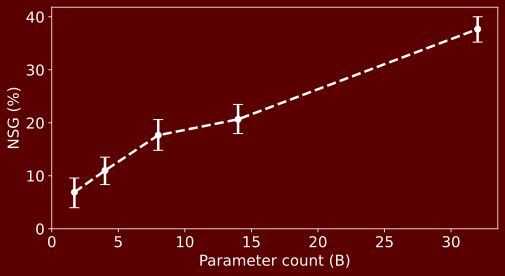

In [39]:
df = pd.read_csv("../experiments/combined/qwen_3/results.csv")
df['parameter_count'] = df['model'].map(lambda x: float(x.split("-")[-1].split("B")[0]))
df = df[df['parameter_count']>1]
df = df.sort_values('parameter_count')
fig, ax = plt.subplots(figsize=(8, 4))

# Make figure background dark red
fig.patch.set_facecolor('#5b0000ff')  # Dark red
ax.set_facecolor('#5b0000ff')  # Dark red

# Plot with white color
ax.errorbar(df['parameter_count'], df['normalized_simulatability_gain'], 
yerr=[df['normalized_simulatability_gain'] - df['normalized_gain_ci_lower'],
                  df['normalized_gain_ci_upper'] - df['normalized_simulatability_gain']],
linestyle='--', marker='o', capsize=5, color='white', 
ecolor='white', markerfacecolor='white', markeredgecolor='white',
linewidth=2.5, elinewidth=2.5)  # Added these two parameters
# Set white color for spines, ticks, and labels

ax.spines['bottom'].set_color('white')
ax.spines['top'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['right'].set_color('white')
ax.tick_params(colors='white', labelsize=15)
# Add axis labels
ax.set_xlabel('Parameter count (B)', color='white', fontsize=15)
ax.set_ylabel('NSG (%)', color='white', fontsize=15)
# Set both axes to start at 0
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.savefig("../figures/poster_fig.png", transparent=True, dpi=300, bbox_inches='tight')
plt.show()

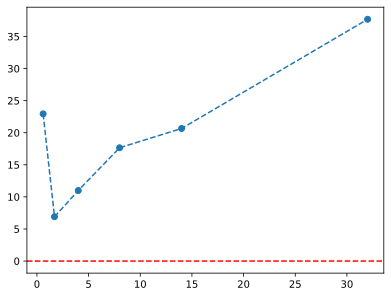